In [3]:
"""
 Q-learning Agent
 1. Choosing actions(with exploration vs exploitation)
 2. Learning from experience(updating Q-values)
 3. Managing exploration(reducing randomness overtime)
 
 Exploration: try new actions to learn about the environment
 Exploitation: Use current knowledge to get the best reward
"""

from collections import defaultdict
import gymnasium as gym
import numpy as np

class BlackjackAgent:
    def __init__(
        self,
        env:gym.Env,
        learning_rate: float,
        initial_epsilon: float,
        epsilon_decay: float,
        final_epsilon: float,
        discount_factor: float=0.95,
    ):
        """Initialize a Q-Learning agent.

        Args:
            env: The training environment
            learning_rate: How quickly to update Q-values (0-1)
            initial_epsilon: Starting exploration rate (usually 1.0)
            epsilon_decay: How much to reduce epsilon each episode
            final_epsilon: Minimum exploration rate (usually 0.1)
            discount_factor: How much to value future rewards (0-1)
        """
        self.env = env
        
        # Q-table: maps(state, action) to expected reward
        # defaultdict automatically creates entries with zeros for new state
        self.q_values = defaultdict(lambda: np.zeros(env.action_space.n))
        
        self.lr = learning_rate
        self.discount_factor = discount_factor # toward future reward

        self.epsilon = initial_epsilon
        self.epsilon_decay = epsilon_decay
        self.final_epsilon = final_epsilon
        
        self.training_error = [] # track
        
    def get_action(self, obs: tuple[int,int,bool])-> int:
        """ choose an action, ep-greedy

        Returns:
            action: 0 stand / 1 hit
        """
        # with p = e: explore
        if np.random.random() < self.epsilon:
            return self.env.action_space.sample()
        
        # p = 1-e: exploit, obs [player_sum, dealer_card, usable_ace]
        else:
            return int(np.argmax(self.q_values[obs]))
    
    def update(
        self,
        obs: tuple[int, int, bool],
        action: int,
        reward: float,
        terminated: bool,
        next_obs:tuple[int, int,bool]
    ):
        """
        update Q-value based on experience
        This is the heart of Q-learning: learn from (state, action, reward, next_state)
        """
        future_q_value = (not terminated) * np.max(self.q_values[next_obs])
        
        target = reward + self.discount_factor * future_q_value # Q-value Bellman equation
        temporal_difference = target - self.q_values[obs][action]
        
        self.q_values[obs][action] = (self.q_values[obs][action] + self.lr * temporal_difference)
        
        self.training_error.append(temporal_difference)

    def decay_epsilon(self):
        self.epsilon = max(self.final_epsilon, self.epsilon - self.epsilon_decay)
       

In [5]:
     
learning_rate = 0.01 # how fast to learn
n_episodes = 100_000 # num of hands to practice
start_epsilon = 1.0 # random
epsilon_decay = start_epsilon / (n_episodes/2)
final_epsilon = 0.1
""" 
Q-Learning 超参数解析      

  1. 学习率 (learning_rate / α)                                                      
   
  learning_rate = 0.01  # 0.01 ~ 0.1 常用                                            
                  
  - 含义：每次更新 Q 值时，新信息占多大比重
  - 影响：
    - 高 (≈1)：快速学习，但不稳定，容易遗忘之前经验
    - 低 (≈0.01)：学习慢，但更稳定，积累经验更平滑
    - 常用范围：0.01 ~ 0.1

  2. 训练轮数 (n_episodes)

  n_episodes = 100_000

  - 含义：让 agent 玩多少把游戏
  - 影响：不够则学不会，太多则浪费时间
  - -v1 通常 10000-50000 就能达到 500 满分

  3. Epsilon (ε) - 探索 vs 利用

  这是 Q-Learning 的核心概念：

  ε = 概率选择"随机动作"（探索）
  1-ε = 概率选择"最优动作"（利用）

  start_epsilon = 1.0      # 开头 100% 随机探索
  epsilon_decay = start_epsilon / (n_episodes/2)  # 衰减速度
  final_epsilon = 0.1     # 最后保留 10% 随机，防止完全僵化

  Epsilon 衰减过程

  Episode 0:      ε = 1.0     → 100% 随机（完全探索）
  Episode 25000:  ε = 0.5     → 50% 随机
  Episode 50000:  ε = 0.1     → 10% 随机（主要利用）
  Episode 100000: ε = 0.1     → 保持 10%
"""
# Create environment and agent
env = gym.make("Blackjack-v1", sab=False)
env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length=n_episodes)

agent = BlackjackAgent(
    env=env,
    learning_rate=learning_rate,
    initial_epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
)

In [6]:

from tqdm import tqdm
    
for episode in tqdm(range(n_episodes)):
    obs, info = env.reset()
    done = False
    
    while not done:
        action = agent.get_action(obs)
        
        next_obs,reward, terminated, truncated, info = env.step(action)
        
        agent.update(obs, action, reward, terminated, next_obs)
        
        done = terminated or truncated
        obs = next_obs
        
    agent.decay_epsilon()
    


100%|██████████| 100000/100000 [00:03<00:00, 28650.77it/s]


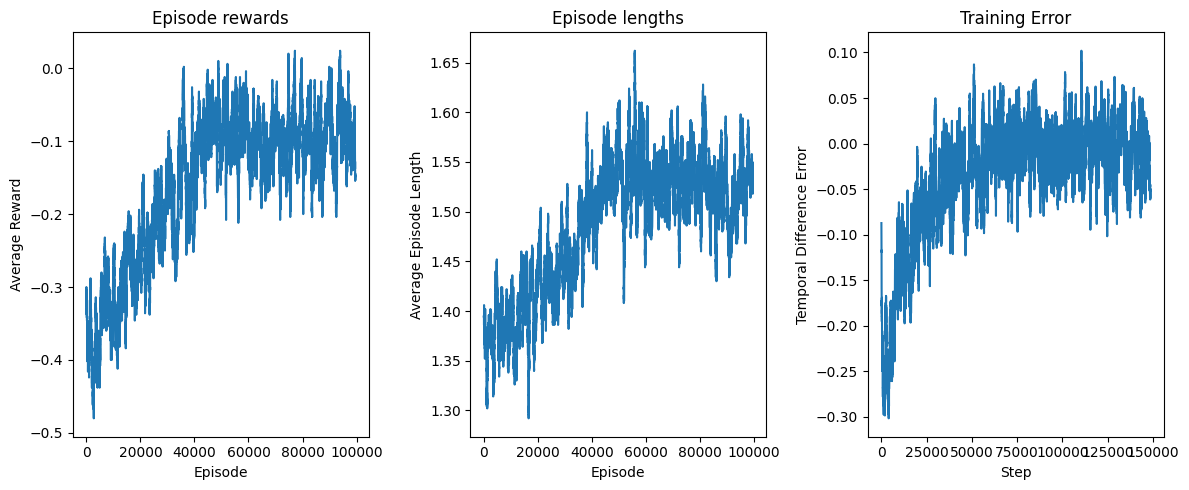

In [8]:

from matplotlib import pyplot as plt

def get_moving_avgs(arr, window, convolution_mode):
    """Compute moving average to smooth noisy data."""
    return np.convolve(
        np.array(arr).flatten(),
        np.ones(window),
        mode=convolution_mode
    ) / window

# Smooth over a 500-episode window
rolling_length = 500
fig, axs = plt.subplots(ncols=3, figsize=(12, 5))

# Episode rewards (win/loss performance)
axs[0].set_title("Episode rewards")
reward_moving_average = get_moving_avgs(
    env.return_queue,
    rolling_length,
    "valid"
)
axs[0].plot(range(len(reward_moving_average)), reward_moving_average)
axs[0].set_ylabel("Average Reward")
axs[0].set_xlabel("Episode")

# Episode lengths (how many actions per hand)
axs[1].set_title("Episode lengths")
length_moving_average = get_moving_avgs(
    env.length_queue,
    rolling_length,
    "valid"
)
axs[1].plot(range(len(length_moving_average)), length_moving_average)
axs[1].set_ylabel("Average Episode Length")
axs[1].set_xlabel("Episode")

# Training error (how much we're still learning)
axs[2].set_title("Training Error")
training_error_moving_average = get_moving_avgs(
    agent.training_error,
    rolling_length,
    "same"
)
axs[2].plot(range(len(training_error_moving_average)), training_error_moving_average)
axs[2].set_ylabel("Temporal Difference Error")
axs[2].set_xlabel("Step")

plt.tight_layout()
plt.show()        
        
        
        

In [9]:
# Test the trained agent
def test_agent(agent, env, num_episodes=1000):
    """Test agent performance without learning or exploration."""
    total_rewards = []

    # Temporarily disable exploration for testing
    old_epsilon = agent.epsilon
    agent.epsilon = 0.0  # Pure exploitation

    for _ in range(num_episodes):
        obs, info = env.reset()
        episode_reward = 0
        done = False

        while not done:
            action = agent.get_action(obs)
            obs, reward, terminated, truncated, info = env.step(action)
            episode_reward += reward
            done = terminated or truncated

        total_rewards.append(episode_reward)

    # Restore original epsilon
    agent.epsilon = old_epsilon

    win_rate = np.mean(np.array(total_rewards) > 0)
    average_reward = np.mean(total_rewards)

    print(f"Test Results over {num_episodes} episodes:")
    print(f"Win Rate: {win_rate:.1%}")
    print(f"Average Reward: {average_reward:.3f}")
    print(f"Standard Deviation: {np.std(total_rewards):.3f}")

# Test your agent
test_agent(agent, env)

Test Results over 1000 episodes:
Win Rate: 42.0%
Average Reward: -0.071
Standard Deviation: 0.952
